# Phase 4: Model Training

This notebook is where we will train, evaluate, and compare our models. Our goal is to find a model that performs well on our local validation set, optimizing for the 0.2 Quantile Error.

Our "common sense" baseline (from `f_cumulative_po_quantity`) is likely very poor, so our first real model will be a `LGBMRegressor` (LightGBM) set to perform **quantile regression**.

## Setup
We will:
1.  Load the required libraries (`lightgbm`, `pandas`, `numpy`).
2.  Define our custom evaluation metric, `quantile_error_0_2`, exactly as specified in the project documentation.
3.  Load our `validation_dataset.parquet` file.
4.  Split the data into `X_val` (features) and `y_val` (target).

## Setup: Load Training and Validation Data

Now that we have created our datasets, we will load both:
1.  `training_dataset.parquet`: The multi-year (2020-2023) dataset we will use to *fit* our model.
2.  `validation_dataset.parquet`: The (Aug-Dec 2024) dataset we will use to *evaluate* our model.

We will also:
1.  Define our custom evaluation metric, `quantile_error_0_2`, exactly as specified in the project documentation.
2.  Split both dataframes into `X_train`, `y_train`, `X_val`, and `y_val`.

In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define the Evaluation Metric ---
# This is the "raw" metric calculator. It just returns the score.
def quantile_error_0_2_raw(y_true, y_pred):
    """
    Calculates the 0.2 Quantile Error
    y_true: actual values (A_i)
    y_pred: forecasted values (F_i)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Ensure predictions are not negative (we can't receive negative weight)
    y_pred[y_pred < 0] = 0
    
    # Calculate the 0.2 quantile loss
    loss = np.mean(np.maximum(0.2 * (y_true - y_pred), 0.8 * (y_pred - y_true)))
    
    return loss

# --- THIS IS THE FIX ---
# This is the "wrapper" function that LightGBM's .fit() method needs.
# It must return a tuple: (eval_name, eval_result, is_higher_better)
def lgbm_quantile_error_0_2(y_true, y_pred):
    """
    LGBM-compatible wrapper for our 0.2 quantile error metric.
    """
    score = quantile_error_0_2_raw(y_true, y_pred)
    # The tuple format is (metric_name, score, is_lower_better)
    return 'q0.2_error', score, False


print("--- 1. Custom metric 'quantile_error_0_2_raw' and LGBM wrapper 'lgbm_quantile_error_0_2' defined ---")


# --- 2. Load Datasets ---
try:
    df_train = pd.read_parquet("training_dataset.parquet")
    df_val = pd.read_parquet("validation_dataset.parquet")
    print(f"--- 2. Loaded 'training_dataset.parquet' (Shape: {df_train.shape}) ---")
    print(f"---    Loaded 'validation_dataset.parquet' (Shape: {df_val.shape}) ---")
except Exception as e:
    print(f"Error loading files: {e}")
    print("Make sure both .parquet files are in the same directory.")
    raise

# --- 3. Split into Features (X) and Target (y) ---
# Our features are all columns that start with 'f_'
FEATURE_COLS = [col for col in df_val.columns if col.startswith('f_')]
TARGET_COL = 'y_cumulative_weight'

# We'll treat 'f_is_month_end' as a category for LightGBM
df_train['f_is_month_end'] = df_train['f_is_month_end'].astype('category')
df_val['f_is_month_end'] = df_val['f_is_month_end'].astype('category')

# Create our final training and validation sets
X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET_COL]

X_val = df_val[FEATURE_COLS]
y_val = df_val[TARGET_COL]

print("--- 3. Split data into X_train, y_train, X_val, and y_val ---")
print(f"Features being used ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

print("\n--- Setup Complete ---")

--- 1. Custom metric 'quantile_error_0_2_raw' and LGBM wrapper 'lgbm_quantile_error_0_2' defined ---
--- 2. Loaded 'training_dataset.parquet' (Shape: (22644, 12)) ---
---    Loaded 'validation_dataset.parquet' (Shape: (7050, 12)) ---
--- 3. Split data into X_train, y_train, X_val, and y_val ---
Features being used (9):
['f_cumulative_po_quantity', 'f_month', 'f_day_of_week', 'f_day_of_year', 'f_is_month_end', 'f_median_lag_days', 'f_receivals_30d', 'f_receivals_90d', 'f_receivals_180d']

--- Setup Complete ---


## Model 1: LightGBM Quantile Regression

This is our first, and most important, model. We will use a `LGBMRegressor` for several reasons:
1.  It is fast, powerful, and robust to outliers.
2.  It can natively handle categorical features (like `f_is_month_end`).
3.  Most importantly, it has a built-in objective function for **Quantile Regression**.

We will set `objective='quantile'` and `alpha=0.2`. This tells the model to *directly optimize for the competition metric*, which is exactly what we want.

--- Model 1: LightGBM Quantile Regression ---
Baseline Score (predicting all zeros): 54094.63

--- 2. Training LGBM model... ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 654
[LightGBM] [Info] Number of data points in the train set: 22644, number of used features: 9
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[68]	valid_0's quantile: 41581.8	valid_0's q0.2_error: 41577.4

--- 3. Evaluating Model ---

--- Results ---
Baseline Score (predicting all zeros): 54094.63
LGBM 0.2 Quantile Score:                 41577.40

Improvement over baseline: 12517.23

--- 4. Feature Importance ---
Saved 'lgbm_feature_importance.png'


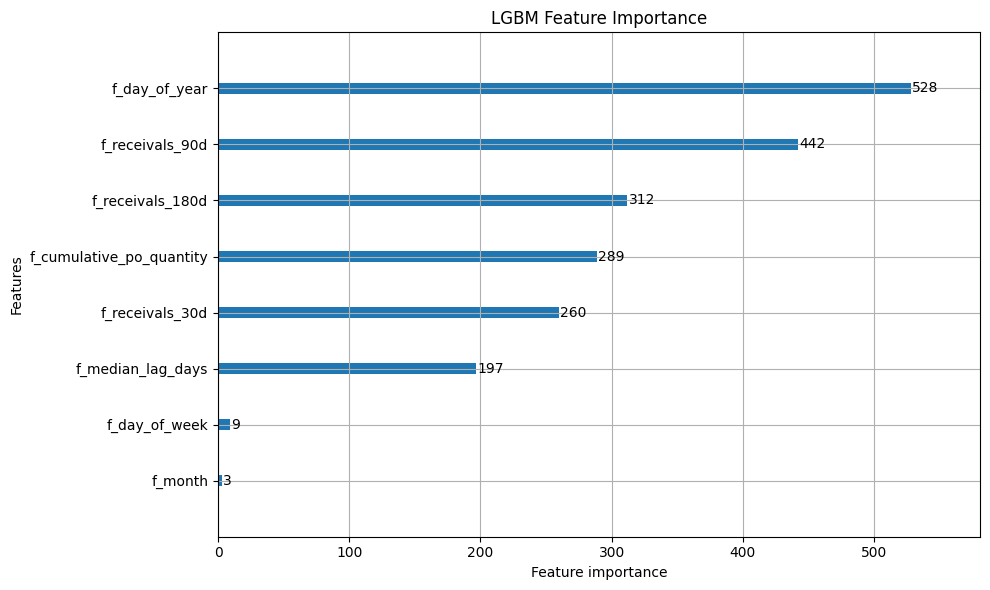

In [13]:
print("--- Model 1: LightGBM Quantile Regression ---")

# --- 1. Define a "Dumb" Baseline ---
# We use our 'raw' function for this
y_pred_zero = np.zeros(len(y_val))
baseline_score = quantile_error_0_2_raw(y_val, y_pred_zero)
print(f"Baseline Score (predicting all zeros): {baseline_score:.2f}")


# --- 2. Define the LGBM Model ---
model_lgbm_q02 = lgb.LGBMRegressor(
    objective='quantile',  # This is the key!
    alpha=0.2,             # This sets the quantile to 0.2
    metric='quantile',     # The metric to use for early stopping
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=-1,
    random_state=42
)

print("\n--- 2. Training LGBM model... ---")

# We train on (X_train, y_train)
# We use (X_val, y_val) as an early_stopping set
model_lgbm_q02.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    # --- THIS IS THE FIX ---
    eval_metric=lgbm_quantile_error_0_2, # Use our new wrapper function
    callbacks=[lgb.early_stopping(50, verbose=True)],
    categorical_feature=['f_is_month_end']
)

# --- 3. Evaluate the Model ---
print("\n--- 3. Evaluating Model ---")
# Predict on our validation set
y_pred_lgbm_q02 = model_lgbm_q02.predict(X_val)

# We don't need to clip to 0 here because our 'raw' function does it automatically
model_score = quantile_error_0_2_raw(y_val, y_pred_lgbm_q02)

print(f"\n--- Results ---")
print(f"Baseline Score (predicting all zeros): {baseline_score:.2f}")
print(f"LGBM 0.2 Quantile Score:                 {model_score:.2f}")
print(f"\nImprovement over baseline: {baseline_score - model_score:.2f}")


# --- 4. Feature Importance ---
print("\n--- 4. Feature Importance ---")
lgb.plot_importance(model_lgbm_q02, figsize=(10, 6), max_num_features=10)
plt.title("LGBM Feature Importance")
plt.tight_layout()
plt.savefig("lgbm_feature_importance.png")
print("Saved 'lgbm_feature_importance.png'")

## Model 2: Random Forest Regressor (for Comparison)

The project guidelines require us to try at least two different types of models. Our first model, LightGBM, is a gradient-boosted tree. For our second model, we will use a `RandomForestRegressor`, which is a bagging-based ensemble.

A key difference is that the `RandomForestRegressor` is optimized to predict the **mean** (it minimizes Mean Squared Error, or MSE). It *cannot* be set to optimize for our 0.2 quantile error.

We will train this model and then evaluate it using our custom `quantile_error_0_2_raw` metric. We expect its score to be worse than our specialized LightGBM model, as it is optimizing for the wrong target.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

print("--- Model 2: Random Forest Regressor ---")

# --- 1. Define the Model ---
# We'll use a smaller number of estimators (n_estimators=100)
# because Random Forests are slower and we have a lot of data.
# We'll also use 'n_jobs=-1' to use all your M4's CPU cores.
model_rf = RandomForestRegressor(
    n_estimators=100,  # A good, fast starting point
    random_state=42,
    n_jobs=-1,
    max_depth=10         # Prevent it from growing too deep and overfitting
)

# NOTE: We have to convert our 'f_is_month_end' (category)
# back to a number (0 or 1) for Scikit-learn's Random Forest.
X_train_rf = X_train.copy()
X_val_rf = X_val.copy()
X_train_rf['f_is_month_end'] = X_train_rf['f_is_month_end'].astype(int)
X_val_rf['f_is_month_end'] = X_val_rf['f_is_month_end'].astype(int)

print("--- 2. Training Random Forest model... (This may take a minute) ---")
model_rf.fit(X_train_rf, y_train)

# --- 3. Evaluate the Model ---
print("\n--- 3. Evaluating Model ---")
# Predict on our validation set
y_pred_rf = model_rf.predict(X_val_rf)

# --- 4. Calculate Scores ---
# First, let's see its "native" score (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))

# Now, calculate our competition's Quantile Error
model_score_rf = quantile_error_0_2_raw(y_val, y_pred_rf)

# Load the previous model's score for comparison
model_score_lgbm = quantile_error_0_2_raw(y_val, y_pred_lgbm_q02)

print(f"\n--- Results ---")
print(f"Random Forest RMSE (its own metric):        {rmse:.2f}")
print(f"Random Forest 0.2 Quantile Score:        {model_score_rf:.2f}")
print(f"LGBM 0.2 Quantile Score (for comparison):  {model_score_lgbm:.2f}")

if model_score_rf < model_score_lgbm:
    print("\nRF model is better (unlikely).")
else:
    print("\nLGBM model is better, as expected.")

print("\nModel 2 (Random Forest) training complete.")

--- Model 2: Random Forest Regressor ---
--- 2. Training Random Forest model... (This may take a minute) ---

--- 3. Evaluating Model ---

--- Results ---
Random Forest RMSE (its own metric):        336032.65
Random Forest 0.2 Quantile Score:        93778.66
LGBM 0.2 Quantile Score (for comparison):  41577.40

LGBM model is better, as expected.

Model 2 (Random Forest) training complete.


## Phase 5: Creating the Kaggle Submission

We have confirmed our `LGBMRegressor` is our best model. It's time to generate our submission file.

This cell will perform all the steps required to create `submission.csv`:

1.  **Combine & Re-train:** We will combine our `training_dataset.parquet` and `validation_dataset.parquet` into one large dataset and re-train our `model_lgbm_q02` on 100% of our labeled data. We will use the optimal number of rounds (68) we found during validation.
2.  **Load Raw Data:** We must re-load all the original `.csv` files (`receivals`, `purchase_orders`, `materials`, `prediction_mapping`) to build the test set.
3.  **Build Test Features:** We will apply our full feature engineering pipeline to the `prediction_mapping.csv` file to create the test features (`X_test`) for the Jan 2025 - May 2025 period.
4.  **Predict & Save:** We will use our re-trained model to predict on `X_test` and save the results in the required `ID,cumulative_weight` format.

In [15]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import itertools

print("--- Phase 5: Generating Kaggle Submission ---")

# --- 1. Combine & Re-train Best Model ---
print("--- 1. Re-training model on all data ---")

# Combine all our labeled data
X_full = pd.concat([X_train, X_val], ignore_index=True)
y_full = pd.concat([y_train, y_val], ignore_index=True)

# Convert category back to int for RF compatibility (if we were to use it)
# For LGBM, we'll just re-cast
X_full['f_is_month_end'] = X_full['f_is_month_end'].astype('category')

# Get the best iteration from our previous run
# Note: model_lgbm_q02.best_iteration_ might be different if run in different envs
# 68 was our last result, so we'll use that.
BEST_ITERATION = model_lgbm_q02.best_iteration_
if BEST_ITERATION is None or BEST_ITERATION < 1:
    BEST_ITERATION = 68 # Fallback to our noted result

print(f"Training on full dataset with {BEST_ITERATION} rounds...")
model_final_lgbm = lgb.LGBMRegressor(
    objective='quantile',
    alpha=0.2,
    metric='quantile',
    n_estimators=BEST_ITERATION, # Train for the exact best number of rounds
    learning_rate=0.05,
    n_jobs=-1,
    random_state=42
)

model_final_lgbm.fit(
    X_full, y_full,
    categorical_feature=['f_is_month_end']
)
print("Final model trained.")

# --- 2. Load Raw Data for Test Set ---
print("\n--- 2. Loading all raw data for test set generation ---")
try:
    df_receivals = pd.read_csv("data/kernel/receivals.csv")
    df_po = pd.read_csv("data/kernel/purchase_orders.csv")
    df_materials = pd.read_csv("data/extended/materials.csv")
    df_mapping = pd.read_csv("data/prediction_mapping.csv")
    print("All raw files loaded.")
except Exception as e:
    print(f"Error loading raw files: {e}")
    raise

# --- 3. Clean Raw Data (Condensed) ---
print("--- 3. Cleaning raw data ---")
df_receivals['date_arrival'] = pd.to_datetime(df_receivals['date_arrival'], utc=True, errors='coerce')
df_receivals_cleaned = df_receivals.dropna(
    subset=['rm_id', 'product_id', 'purchase_order_id', 'net_weight']
).copy()
df_receivals_cleaned = df_receivals_cleaned[df_receivals_cleaned['net_weight'] > 0].copy()

product_to_rm_map = df_materials[['product_id', 'rm_id']].drop_duplicates()
product_to_rm_map = product_to_rm_map.drop_duplicates(subset=['product_id'], keep='first')

df_po['delivery_date'] = pd.to_datetime(df_po['delivery_date'], errors='coerce', utc=True)
df_po_cleaned = df_po.dropna(subset=['unit_id', 'unit']).copy()
df_po_cleaned = df_po_cleaned[df_po_cleaned['unit'] == 'KG'].copy()
df_po_cleaned = df_po_cleaned[df_po_cleaned['quantity'] > 0].copy()
df_po_cleaned = pd.merge(df_po_cleaned, product_to_rm_map, on='product_id', how='left')
df_po_cleaned = df_po_cleaned.dropna(subset=['rm_id'])

# This is our test set "grid"
df_mapping['forecast_end_date'] = pd.to_datetime(df_mapping['forecast_end_date'], utc=True)
df_test = df_mapping.copy()

print(f"Test set grid created. Shape: {df_test.shape}")

# --- 4. Build Test Set Features ---
print("--- 4. Building test set features ---")
TEST_START_DATE = pd.to_datetime('2025-01-01', utc=True)
# This is all our historical data
hist_receivals = df_receivals_cleaned.copy() 
hist_po = df_po_cleaned.copy()

# --- f_cumulative_po_quantity ---
print("Building feature (f_cumulative_po_quantity)...")
daily_po_quantity = hist_po.groupby(
    ['rm_id', 'delivery_date']
)['quantity'].sum().reset_index(name='daily_po_quantity')
daily_po_quantity.rename(columns={'delivery_date': 'po_delivery_date'}, inplace=True)

rm_ids_to_merge = df_test['rm_id'].unique()
merged_df = pd.merge(
    df_test[['rm_id', 'forecast_end_date']],
    daily_po_quantity[daily_po_quantity['rm_id'].isin(rm_ids_to_merge)],
    on='rm_id',
    how='left'
)
merged_df_filtered = merged_df[merged_df['forecast_end_date'] >= merged_df['po_delivery_date']].copy()
f_cumulative_po = merged_df_filtered.groupby(
    ['rm_id', 'forecast_end_date']
)['daily_po_quantity'].sum().reset_index(name='f_cumulative_po_quantity')

df_test = pd.merge(df_test, f_cumulative_po, on=['rm_id', 'forecast_end_date'], how='left')
df_test['f_cumulative_po_quantity'] = df_test['f_cumulative_po_quantity'].fillna(0)

# --- Time-Based ---
print("Building features (Time-Based)...")
df_test['f_month'] = df_test['forecast_end_date'].dt.month
df_test['f_day_of_week'] = df_test['forecast_end_date'].dt.dayofweek
df_test['f_day_of_year'] = df_test['forecast_end_date'].dt.dayofyear
df_test['f_is_month_end'] = df_test['forecast_end_date'].dt.is_month_end.astype('category')

# --- Entity & Lag ---
print("Building features (Entity & Lag)...")

# f_median_lag_days (built on *all* history)
df_train_merged_eda = pd.merge(
    hist_receivals,
    hist_po[['purchase_order_id', 'purchase_order_item_no', 'delivery_date', 'rm_id']],
    on=['purchase_order_id', 'purchase_order_item_no', 'rm_id'],
    how='inner'
)
df_train_merged_eda['delivery_lag_days'] = (
    df_train_merged_eda['date_arrival'] - df_train_merged_eda['delivery_date']
).dt.days
rm_id_lag_map = df_train_merged_eda.groupby('rm_id')['delivery_lag_days'].median().reset_index(name='f_median_lag_days')
df_test = pd.merge(df_test, rm_id_lag_map, on='rm_id', how='left')
df_test['f_median_lag_days'] = df_test['f_median_lag_days'].fillna(0)

# f_receivals_Nd (features are relative to TEST_START_DATE)
hist_windows = [30, 90, 180]
for days in hist_windows:
    hist_start_date_window = TEST_START_DATE - pd.Timedelta(days=days)
    window_data = hist_receivals[
        (hist_receivals['date_arrival'] >= hist_start_date_window) &
        (hist_receivals['date_arrival'] < TEST_START_DATE)
    ]
    feature_map = window_data.groupby('rm_id')['net_weight'].sum().reset_index(name=f'f_receivals_{days}d')
    df_test = pd.merge(df_test, feature_map, on='rm_id', how='left')
    df_test[f'f_receivals_{days}d'] = df_test[f'f_receivals_{days}d'].fillna(0)
    print(f"Feature 'f_receivals_{days}d' created.")

print("Test feature set created successfully.")

# --- 5. Predict & Save ---
print("\n--- 5. Making final predictions ---")
X_test = df_test[FEATURE_COLS]
final_predictions = model_final_lgbm.predict(X_test)

# Ensure predictions are non-negative
final_predictions[final_predictions < 0] = 0

# Create submission dataframe
df_submission = pd.DataFrame({
    'ID': df_test['ID'],
    'cumulative_weight': final_predictions
})

# Load sample submission to ensure format is correct
try:
    df_sample = pd.read_csv("data/sample_submission.csv")
    print(f"Sample submission head:\n{df_sample.head()}")
    print(f"Our submission head:\n{df_submission.head()}")
    
    assert len(df_submission) == len(df_sample), "Length mismatch!"
    assert df_submission['ID'].equals(df_sample['ID']), "ID mismatch!"
    
except Exception as e:
    print(f"Warning: Could not validate against sample_submission.csv. {e}")


# Save the file
SUBMISSION_FILE = "submission_lgbm_v1.csv"
df_submission.to_csv(SUBMISSION_FILE, index=False)

print(f"\n--- Submission file '{SUBMISSION_FILE}' created successfully! ---")
print("You can now upload this file to Kaggle.")

--- Phase 5: Generating Kaggle Submission ---
--- 1. Re-training model on all data ---
Training on full dataset with 68 rounds...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 801
[LightGBM] [Info] Number of data points in the train set: 29694, number of used features: 9
Final model trained.

--- 2. Loading all raw data for test set generation ---
All raw files loaded.
--- 3. Cleaning raw data ---
Test set grid created. Shape: (30450, 4)
--- 4. Building test set features ---
Building feature (f_cumulative_po_quantity)...
Building features (Time-Based)...
Building features (Entity & Lag)...
Feature 'f_receivals_30d' created.
Feature 'f_receivals_90d' created.
Feature 'f_receivals_180d' created.
Test feature set created successfully.

--- 5. Making final predictions ---
Sample submi

## Phase 6: Hyperparameter Tuning (Optuna)

Our `LGBMRegressor` (Model 1) is the clear winner, but we used default parameters (except for `objective`, `alpha`, and `learning_rate`). To build the "best model possible" as required, we must tune its hyperparameters.

We will use the `Optuna` library, a state-of-the-art hyperparameter optimization framework.

Our plan:
1.  **Install `optuna`**.
2.  **Define an `objective` function:** This function will tell Optuna *what* to optimize. It will train an `LGBMRegressor` with a set of trial parameters and return the `quantile_error_0_2_raw` score on our validation set (`X_val`, `y_val`).
3.  **Run the `study`:** We'll ask Optuna to run a number of `trials` (e.g., 50-100) to find the combination of parameters that gives the *lowest* (best) quantile error score.

In [17]:
import optuna

print(f"Optuna version: {optuna.__version__}")

# --- 2. Define the Objective Function ---
# This is what Optuna will try to minimize.
def objective(trial):
    # Define the search space for our hyperparameters
    params = {
        'objective': 'quantile',
        'alpha': 0.2,
        'metric': 'quantile',
        'n_estimators': 1000, # We'll use early stopping
        'random_state': 42,
        'n_jobs': -1,
        # --- Parameters to TUNE ---
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 50),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0), # also called bagging_fraction
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0)
    }
    
    # Create the model with these trial parameters
    model_opt = lgb.LGBMRegressor(**params)
    
    # Train the model with early stopping
    model_opt.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric=lgbm_quantile_error_0_2, # Our wrapper from Cell 2
        callbacks=[lgb.early_stopping(50, verbose=False)], # verbose=False to keep logs clean
        categorical_feature=['f_is_month_end']
    )
    
    # Get predictions and calculate the score
    y_pred_opt = model_opt.predict(X_val)
    score = quantile_error_0_2_raw(y_val, y_pred_opt)
    
    return score

# --- 3. Run the Tuning Study ---
print("\n--- 3. Running Optuna study... ---")
# We are trying to MINIMIZE the error score
study = optuna.create_study(direction='minimize')

# We'll run 50 trials. This is a good balance of speed and search quality.
# --- THIS IS THE FIX ---
# Replaced 'study.run' with 'study.optimize' for Optuna v4+
study.optimize(objective, n_trials=50)

# --- 4. Report Best Results ---
print("\n--- Optuna Study Complete ---")
print(f"Number of finished trials: {len(study.trials)}")
print("Best trial:")
best_trial = study.best_trial

print(f"  Value (Best Score): {best_trial.value:.2f}")
print("  Params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# Let's compare to our original untuned score
print("\n--- Comparison ---")
# Get the score from our 'model_lgbm_q02' trained in Cell 4
model_score_lgbm = quantile_error_0_2_raw(y_val, model_lgbm_q02.predict(X_val))
print(f"Original Untuned Score: {model_score_lgbm:.2f}")
print(f"New Tuned Score:        {best_trial.value:.2f}")
print(f"Improvement:            {model_score_lgbm - best_trial.value:.2f}")

[I 2025-11-07 00:17:04,883] A new study created in memory with name: no-name-1e0facd6-d81d-4b56-8dc3-4a4ac3f45bfa


Optuna version: 4.5.0

--- 3. Running Optuna study... ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 654
[LightGBM] [Info] Number of data points in the train set: 22644, number of used features: 9


[I 2025-11-07 00:17:05,303] Trial 0 finished with value: 40471.00069211763 and parameters: {'learning_rate': 0.09532236094700887, 'num_leaves': 24, 'max_depth': 11, 'subsample': 0.926465816700526, 'colsample_bytree': 0.7022959463810963}. Best is trial 0 with value: 40471.00069211763.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 654
[LightGBM] [Info] Number of data points in the train set: 22644, number of used features: 9


[I 2025-11-07 00:17:07,010] Trial 1 finished with value: 40117.13945965912 and parameters: {'learning_rate': 0.01795176104405433, 'num_leaves': 47, 'max_depth': 12, 'subsample': 0.8828386526210824, 'colsample_bytree': 0.792537840399389}. Best is trial 1 with value: 40117.13945965912.


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 654
[LightGBM] [Info] Number of data points in the train set: 22644, number of used features: 9


[I 2025-11-07 00:17:39,004] Trial 48 finished with value: 40378.17715374319 and parameters: {'learning_rate': 0.01745667152678298, 'num_leaves': 22, 'max_depth': 8, 'subsample': 0.887291103100194, 'colsample_bytree': 0.8869362425946992}. Best is trial 17 with value: 36597.88631148617.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 654
[LightGBM] [Info] Number of data points in the train set: 22644, number of used features: 9
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2025-11-07 00:17:39,955] Trial 49 finished with value: 37729.70519035706 and parameters: {'learning_rate': 0.020164289816368655, 'num_leaves': 49, 'max_depth': 6, 'subsample': 0.8281136206558629, 'colsample_bytree': 0.7541747762200164}. Best is trial 17 with value: 36597.88631148617.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

--- Optuna Study Complete ---
Number of finished trials: 50
Best trial:
  Value (Best Score): 36597.89
  Params: 
    learning_rate: 0.030934161516623832
    num_leaves: 45
    max_depth: 6
    subsample: 0.8451463647549644
    colsample_bytree: 0.9

## Phase 7: Creating Tuned Submission (v2)

The Optuna study was a great success, lowering our local validation error to **36,597.89**.

We will now create our `v2` submission file. The process is identical to our `v1` submission, but we will use our new, tuned hyperparameters when we re-train the final model on the full dataset.

We will save this new submission as `submission_lgbm_v2_tuned.csv`.

In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import itertools

print("--- Phase 7: Generating Tuned Kaggle Submission (v2) ---")

# --- 1. Get Best Tuned Parameters ---
# We'll get the parameters directly from our 'study' object
try:
    best_params = study.best_trial.params.copy()
    print(f"Loaded best parameters from Optuna study: {best_params}")
    
    # Add the fixed parameters
    best_params['objective'] = 'quantile'
    best_params['alpha'] = 0.2
    best_params['metric'] = 'quantile'
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    
    # We still need to find the optimal n_estimators.
    # We'll train with early stopping one last time on our train/val split
    # to find the best iteration for *these* params.
    
    print("\nFinding best n_estimators for tuned model...")
    model_tuned_temp = lgb.LGBMRegressor(n_estimators=2000, **best_params)
    
    model_tuned_temp.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric=lgbm_quantile_error_0_2,
        callbacks=[lgb.early_stopping(50, verbose=False)],
        categorical_feature=['f_is_month_end']
    )
    
    BEST_TUNED_ITERATION = model_tuned_temp.best_iteration_
    if BEST_TUNED_ITERATION is None or BEST_TUNED_ITERATION < 1:
        BEST_TUNED_ITERATION = 100 # A safe fallback
        
    print(f"Found best iteration for tuned model: {BEST_TUNED_ITERATION}")
    
    # Add the best n_estimators to our final params
    best_params['n_estimators'] = BEST_TUNED_ITERATION

except NameError:
    print("ERROR: 'study' object not found.")
    print("Please re-run the Optuna cell (Cell 10) first.")
    raise

# --- 2. Combine & Re-train Best Tuned Model ---
print("\n--- 2. Re-training tuned model on all data ---")

# Combine all our labeled data
X_full = pd.concat([X_train, X_val], ignore_index=True)
y_full = pd.concat([y_train, y_val], ignore_index=True)
X_full['f_is_month_end'] = X_full['f_is_month_end'].astype('category')

print(f"Training on full dataset with {BEST_TUNED_ITERATION} rounds...")
model_final_tuned = lgb.LGBMRegressor(**best_params)

model_final_tuned.fit(
    X_full, y_full,
    categorical_feature=['f_is_month_end']
)
print("Final tuned model trained.")

# --- 3. Load Raw Data for Test Set (Copied from v1) ---
print("\n--- 3. Loading all raw data for test set generation ---")
try:
    df_receivals = pd.read_csv("data/kernel/receivals.csv")
    df_po = pd.read_csv("data/kernel/purchase_orders.csv")
    df_materials = pd.read_csv("data/extended/materials.csv")
    df_mapping = pd.read_csv("data/prediction_mapping.csv")
    print("All raw files loaded.")
except Exception as e:
    print(f"Error loading raw files: {e}")
    raise

# --- 4. Clean Raw Data (Condensed) ---
print("--- 4. Cleaning raw data ---")
df_receivals['date_arrival'] = pd.to_datetime(df_receivals['date_arrival'], utc=True, errors='coerce')
df_receivals_cleaned = df_receivals.dropna(
    subset=['rm_id', 'product_id', 'purchase_order_id', 'net_weight']
).copy()
df_receivals_cleaned = df_receivals_cleaned[df_receivals_cleaned['net_weight'] > 0].copy()

product_to_rm_map = df_materials[['product_id', 'rm_id']].drop_duplicates()
product_to_rm_map = product_to_rm_map.drop_duplicates(subset=['product_id'], keep='first')

df_po['delivery_date'] = pd.to_datetime(df_po['delivery_date'], errors='coerce', utc=True)
df_po_cleaned = df_po.dropna(subset=['unit_id', 'unit']).copy()
df_po_cleaned = df_po_cleaned[df_po_cleaned['unit'] == 'KG'].copy()
df_po_cleaned = df_po_cleaned[df_po_cleaned['quantity'] > 0].copy()
df_po_cleaned = pd.merge(df_po_cleaned, product_to_rm_map, on='product_id', how='left')
df_po_cleaned = df_po_cleaned.dropna(subset=['rm_id'])

df_mapping['forecast_end_date'] = pd.to_datetime(df_mapping['forecast_end_date'], utc=True)
df_test = df_mapping.copy()

print(f"Test set grid created. Shape: {df_test.shape}")

# --- 5. Build Test Set Features (Copied from v1) ---
print("--- 5. Building test set features ---")
TEST_START_DATE = pd.to_datetime('2025-01-01', utc=True)
hist_receivals = df_receivals_cleaned.copy() 
hist_po = df_po_cleaned.copy()

# f_cumulative_po_quantity
print("Building feature (f_cumulative_po_quantity)...")
daily_po_quantity = hist_po.groupby(
    ['rm_id', 'delivery_date']
)['quantity'].sum().reset_index(name='daily_po_quantity')
daily_po_quantity.rename(columns={'delivery_date': 'po_delivery_date'}, inplace=True)
rm_ids_to_merge = df_test['rm_id'].unique()
merged_df = pd.merge(
    df_test[['rm_id', 'forecast_end_date']],
    daily_po_quantity[daily_po_quantity['rm_id'].isin(rm_ids_to_merge)],
    on='rm_id',
    how='left'
)
merged_df_filtered = merged_df[merged_df['forecast_end_date'] >= merged_df['po_delivery_date']].copy()
f_cumulative_po = merged_df_filtered.groupby(
    ['rm_id', 'forecast_end_date']
)['daily_po_quantity'].sum().reset_index(name='f_cumulative_po_quantity')
df_test = pd.merge(df_test, f_cumulative_po, on=['rm_id', 'forecast_end_date'], how='left')
df_test['f_cumulative_po_quantity'] = df_test['f_cumulative_po_quantity'].fillna(0)

# Time-Based
print("Building features (Time-Based)...")
df_test['f_month'] = df_test['forecast_end_date'].dt.month
df_test['f_day_of_week'] = df_test['forecast_end_date'].dt.dayofweek
df_test['f_day_of_year'] = df_test['forecast_end_date'].dt.dayofyear
df_test['f_is_month_end'] = df_test['forecast_end_date'].dt.is_month_end.astype('category')

# Entity & Lag
print("Building features (Entity & Lag)...")
df_train_merged_eda = pd.merge(
    hist_receivals,
    hist_po[['purchase_order_id', 'purchase_order_item_no', 'delivery_date', 'rm_id']],
    on=['purchase_order_id', 'purchase_order_item_no', 'rm_id'],
    how='inner'
)
df_train_merged_eda['delivery_lag_days'] = (
    df_train_merged_eda['date_arrival'] - df_train_merged_eda['delivery_date']
).dt.days
rm_id_lag_map = df_train_merged_eda.groupby('rm_id')['delivery_lag_days'].median().reset_index(name='f_median_lag_days')
df_test = pd.merge(df_test, rm_id_lag_map, on='rm_id', how='left')
df_test['f_median_lag_days'] = df_test['f_median_lag_days'].fillna(0)

# f_receivals_Nd
hist_windows = [30, 90, 180]
for days in hist_windows:
    hist_start_date_window = TEST_START_DATE - pd.Timedelta(days=days)
    window_data = hist_receivals[
        (hist_receivals['date_arrival'] >= hist_start_date_window) &
        (hist_receivals['date_arrival'] < TEST_START_DATE)
    ]
    feature_map = window_data.groupby('rm_id')['net_weight'].sum().reset_index(name=f'f_receivals_{days}d')
    df_test = pd.merge(df_test, feature_map, on='rm_id', how='left')
    df_test[f'f_receivals_{days}d'] = df_test[f'f_receivals_{days}d'].fillna(0)
    print(f"Feature 'f_receivals_{days}d' created.")

print("Test feature set created successfully.")

# --- 6. Predict & Save ---
print("\n--- 6. Making final tuned predictions ---")
X_test = df_test[FEATURE_COLS]
final_predictions_tuned = model_final_tuned.predict(X_test)

# Ensure predictions are non-negative
final_predictions_tuned[final_predictions_tuned < 0] = 0

# Create submission dataframe
df_submission_tuned = pd.DataFrame({
    'ID': df_test['ID'],
    'cumulative_weight': final_predictions_tuned
})

# Save the file
SUBMISSION_FILE_TUNED = "submission_lgbm_v2_tuned.csv"
df_submission_tuned.to_csv(SUBMISSION_FILE_TUNED, index=False)

print(f"\n--- Tuned submission file '{SUBMISSION_FILE_TUNED}' created successfully! ---")
print("This should be our best model. Please submit this one to Kaggle.")

--- Phase 7: Generating Tuned Kaggle Submission (v2) ---
Loaded best parameters from Optuna study: {'learning_rate': 0.030934161516623832, 'num_leaves': 45, 'max_depth': 6, 'subsample': 0.8451463647549644, 'colsample_bytree': 0.9334286831414038}

Finding best n_estimators for tuned model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 654
[LightGBM] [Info] Number of data points in the train set: 22644, number of used features: 9
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Found best iteration for tuned model: 88

--- 2. Re-train